Found __call__ method: GuppyFunctionDefinition(wrapped=RawFunctionDef(_user_set_link_name=None, id=DefId(id=395), name='__call__', defined_at=None, python_func=<function foo.__call__ at 0x1161c1e40>, description='function', unitary_flags=<UnitaryFlags.NoFlags: 0>, metadata=FunctionMetadata(_node_metadata=NodeMetadata({}))))


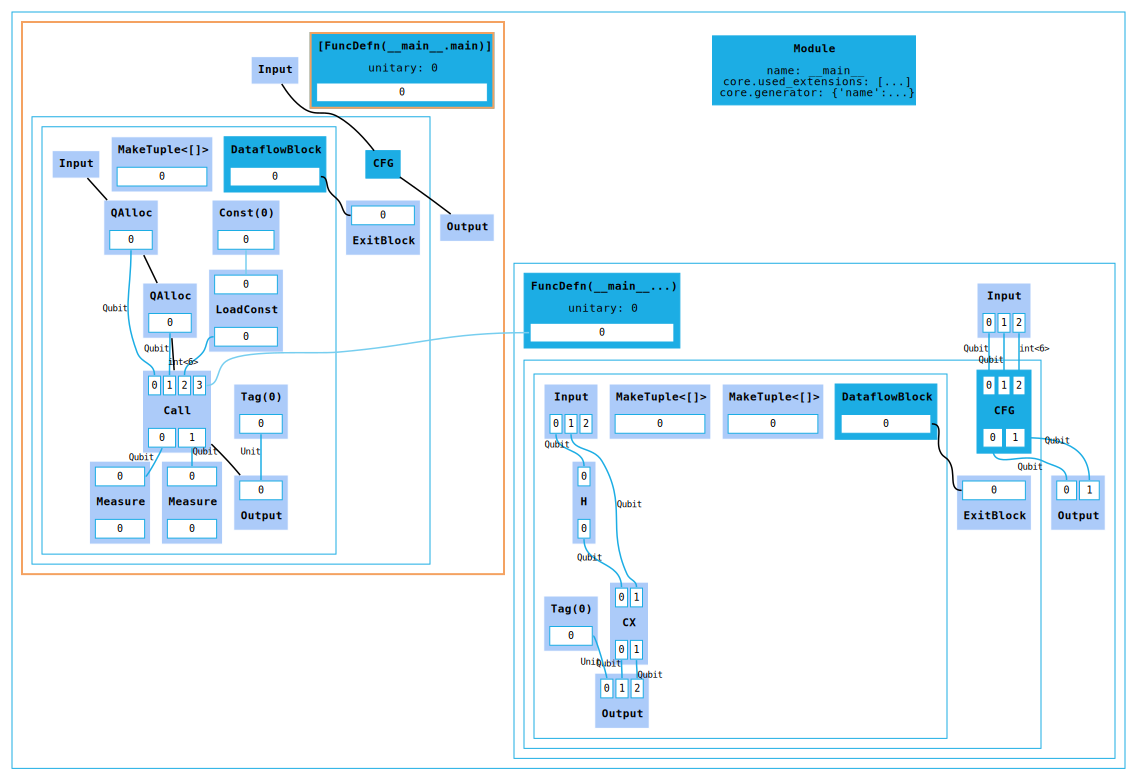

In [2]:
from guppylang.std.builtins import qubit
from guppylang import guppy
from guppylang.std.qsystem import measure
from tests.benchmarks.test_big_array import cx,h


@guppy.unitary
class foo:
    @guppy
    def __call__(q1: qubit, q2: qubit, x: int) -> None:
        h(q1)
        cx(q1, q2)

    @guppy
    def foo_modified(q1: qubit, q2: qubit, x:int) -> None:
        cx(q1, q2)


@guppy
def main() -> None:
    q1 = qubit()
    q2 = qubit()
    foo(q1, q2, 0)
    measure(q1)
    measure(q2)

main.compile().modules[0].render_dot()


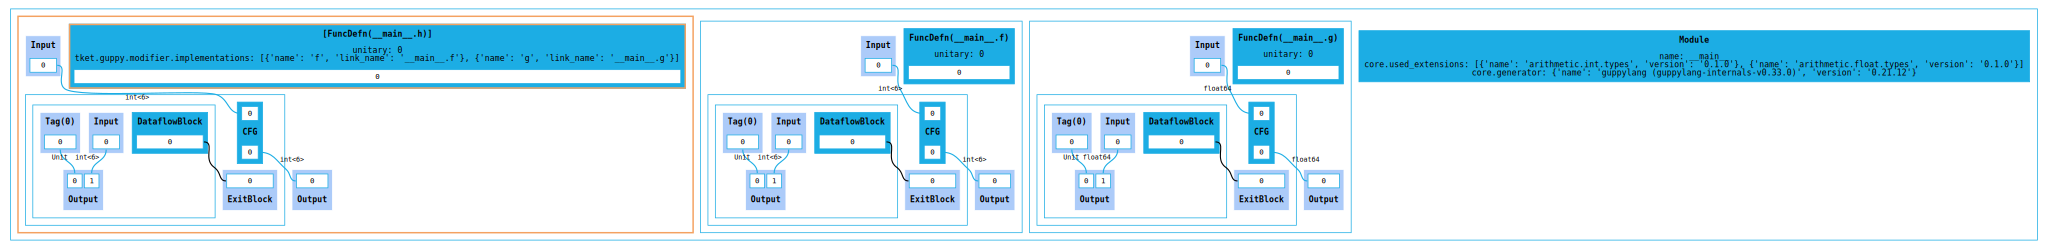

In [7]:
from guppylang import guppy

@guppy()
def g(x: float) -> float:
    return x

@guppy()
def f(x: int) -> int:
    return x

@guppy()
def h(x: int) -> int:
    return x

h.compile_linked(f, g).modules[0].render_dot(RenderConfig(max_node_label_length=None, max_metadata_length=None))

In [1]:


from guppylang.std.builtins import qubit

from tests.benchmarks.test_big_array import cx


@guppy.struct
class Foo:
    q1: qubit

    @guppy
    def __call__(self, q1: qubit, q2: qubit) -> None:
        h(q1)
        cx(q1, q2)

    @guppy.modifier
    def foo_modified[cs: nat](_controls: array[qubit, cs], _power: float=0, _dagger: bool=True):
        self.q1


NameError: name 'guppy' is not defined

In [ ]:
from guppylang.std.builtins import qubit

from tests.benchmarks.test_big_array import cx


@guppy.unitary
class foo:
    @guppy
    def __call__(q1: qubit, q2: qubit, x: int) -> None:
        h(q1)
        cx(q1, q2)

    @guppy.modifier
    def foo_modified[cs: nat](q1: qubit, q2: qubit, x:int,  _controls: array[qubit, cs], _power: float=0, _dagger: bool=True):
        self.q1

        if x > 0:
            # call the default
            with dagger:
                foo(...)
            use_default



foo(q, p): tuple[qubit, qubit] -> None 
foo.foo_modified[2](controls=[q, p], power=0.5, dagger=True): tuple[qubit, qubit] -> None
# the class is seen as a callable:
#   -> in the compilation this should became a FunctionDef with the same signature as class.__call__
#   -> somewhere we need to store also the moifiers functions
#   -> the linking must happed in the metadata of the function

In [ ]:
@guppy.struct
class foo:
    herreq1: qubit
    
    @guppy
    def __call__(self, q1: qubit, q2: qubit) -> None:
        h(q1)
        cx(q1, q2)

    @guppy.modifier
    def foo_modified[cs: nat](q1: qubit, q2: qubit, _controls: array[qubit, cs], _power: float=0, _dagger: bool=True):
        self.q1


f = foo()
f(q, p)

def g(f: Callable[[qubit, qubit], None]) -> None:
    ....

g(f)


In [ ]:
Registers = guppy.type_var("T", copyable=False, droppable=False)
n_ancilla_q = guppy.nat_var("n_ancilla_q")


@guppy.struct
class QPE(Generic[n_ancilla_q, Registers]):
    ancilla_preparation: Callable[[array[qubit, n_ancilla_q]], None]

    @guppy.unitary
    @no_type_check
    class phase_estimate:
        def __call__(
            self,
            phase_reg: array[qubit, n_ancilla_q],
            unitary_regs: Registers,
            power_oracle: Callable[[qubit, Registers, int], None],
        ) -> None:
            self.ancilla_preparation(phase_reg)
            for n_index in range(n_ancilla_q):
                control_index: int = n_ancilla_q - n_index - 1
                power_oracle(phase_reg[control_index], unitary_regs, 2**n_index)
            iqft(phase_reg)

In [ ]:
@guppy(modifier_of=foo)
def foo_modified(qs: array[qubit, 42], controls: array[qubit, n]):
  ...

# double controlled and maybe dagger
@guppy(modifier_of=foo)
def foo_modified(qs: array[qubit, 42], controls: array[qubit, n], dagger: bool):
  ...

# only power
@guppy(modifier_of=foo) #suggestion are welcome
def foo_modified[cs: nat](_power: float):
  ...

@guppy.modifes(dagger=False) #suggestion are welcome

@guppy.modifes(dagger=True) #suggestion are welcome
def foo_modified[cs: nat, _dagger=True]():
  if not _dagger:
    unreachable
  ...
